[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA_baseline.ipynb)

In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}


import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 107 (delta 46), reused 54 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.30 MiB | 13.11 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Success! Files now found: ['Images', 'NCA_baseline.py', 'NCA.py', '.git', 'README.md', 'EBM_NCA.ipynb', 'EBM_NCA_baseline.ipynb', 'utils.py']


In [2]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA_baseline import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 30 #@param {type:"integer"}
WIDTH = 30 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
GENE_COUNT = 3 #@param {type:"integer"} <-- Number of gene channels to use for "private" information
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size
PRIMITIVES_SHAPES = ["Images/square.png", "Images/circle.png", "Images/triangle.png"]
PRIMITIVES_BODY_PARTS = ["Images/Torso.png", "Images/Head.png", "Images/Tail.png", "Images/leg1.png", "Images/leg2.png", "Images/leg3.png", 'Images/leg4.png']
PRIMITIVES_LINES = ["Images/horizontal.png", "Images/Verical.png"]
style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [4]:
#@title Load Primitives { vertical-output: true}

paths = PRIMITIVES_SHAPES #@param {type:"string"}
images = []
images_to_display = []
for path in paths:
    image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)
    images.append(image)
    images_to_display.append(image_to_display)

genes = [[0], [1], [2]] # <-- Gene one hot encoding, indicates which bits if the gene sequence for each encoded "image" should be 1, [0] = 001, [0,1] = 011, [2] = 100 etc. for 3 bits genes. One, one-hot encoding per image, this rule applies for any gene size

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING
assert len(paths) == len(genes), 'Genes and images should have the same length '

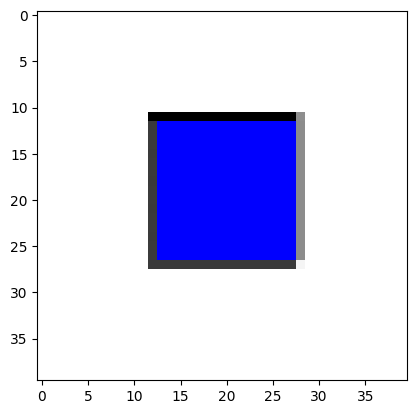

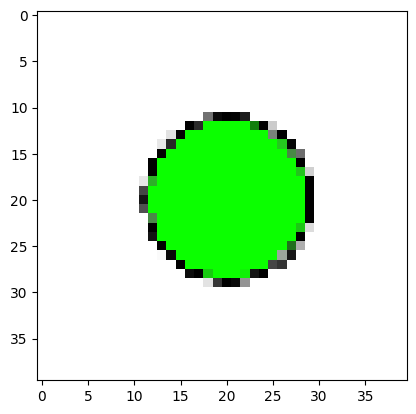

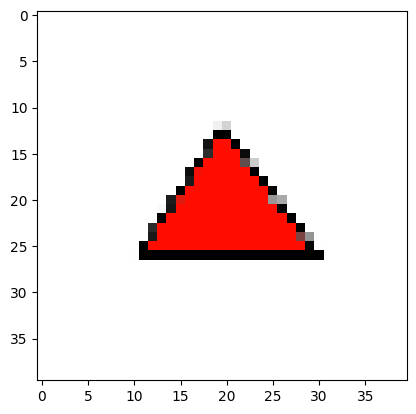

In [5]:
#@title Display Primitives { vertical-output: true}
for i,image in enumerate(images_to_display):
    plt.figure(3+i)
    plt.imshow(image)
pools = []
for gene in genes:
    pools.append(utils.make_gene_pool(gene, pool_size=POOL_SIZE,height=HEIGHT, width=WIDTH, channels=CHANNELS, gene_size=GENE_COUNT, device=DEVICE))
seeds = []
for pool in pools:
    seeds.append(pool[0].clone())

In [6]:
#@title Get Batch Image Partitions { vertical-output: true}
partitions = len(paths)
if partitions == 1:
    part = [BATCH_SIZE]
div = BATCH_SIZE//partitions
rem = BATCH_SIZE % partitions
part = [div + 1 if i < rem else div for i in range(partitions)]
print(f"Batch image paritions = {part}. Batch Size of {BATCH_SIZE}. Number of Partitions = {partitions}")

Batch image paritions = [4, 4, 4]. Batch Size of 12. Number of Partitions = 3


In [7]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [8]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene already exists, all OK!


In [9]:
#@title Initialise NCA { vertical-output: true}
bases = [images[i].tile(part[i],1,1,1) for i in range(len(part))]
base = torch.cat(bases, dim =0 ).to(DEVICE)
loss_log = []
nca = GeneCA(CHANNELS,HIDDEN_SIZE, gene_size=GENE_COUNT)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__ + "_gene_size_" +str(GENE_COUNT)

Batch


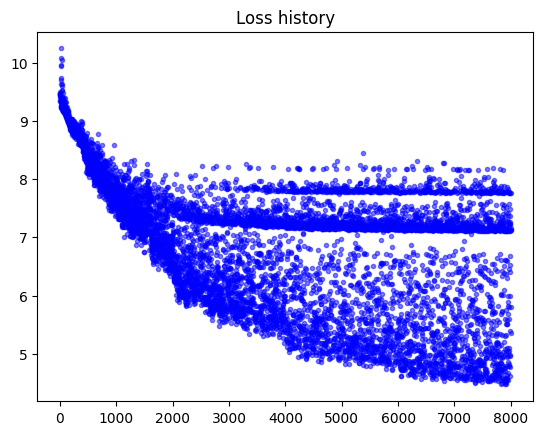

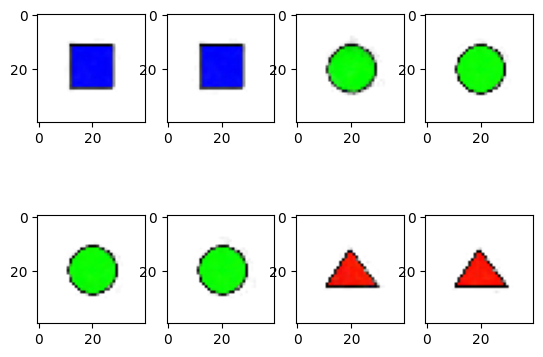

Trained_models/Gene/GeneCA_gene_size_3.pth


In [10]:
#@title Training { vertical-output: true}
for i in range(TRAINING_ITERS + 1):
    loss = 0
    with torch.no_grad():
        idxs, x = utils.get_gene_pool(pools, part, seeds)

    for _ in range( random.randrange(32,92)):
        x = nca(x)
    loss = (base - x[:, :4, :, :]).pow(2).sum() + 0.1 *(perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters) ).pow(2).sum()
    with torch.no_grad():
        loss.backward()
        for p in nca.parameters():
            p.grad /= (p.grad.norm() + 1e-8)
        optim.step()

        x = x.detach()
        optim.zero_grad()

    loss_log.append(loss.log().item())
    with torch.no_grad():
        pools = utils.udate_gene_pool(pools, x.clone().detach(), idxs, part)
    scheduler.step()

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)
    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")



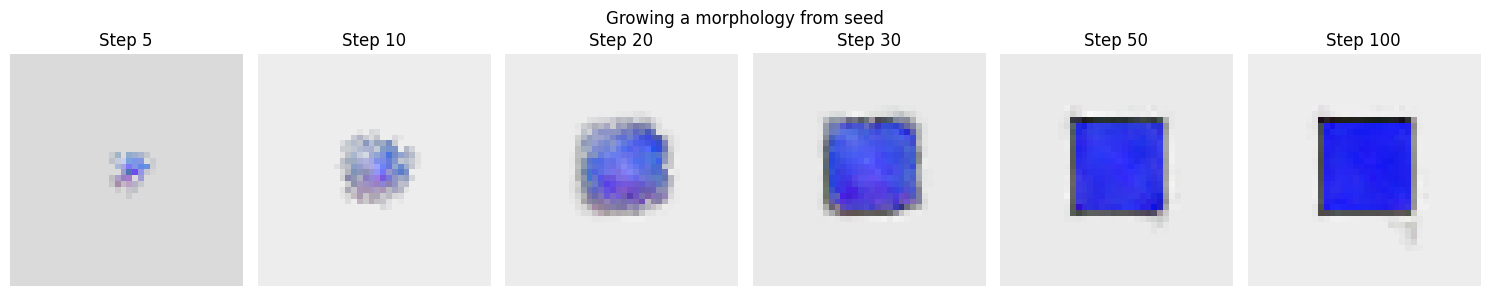

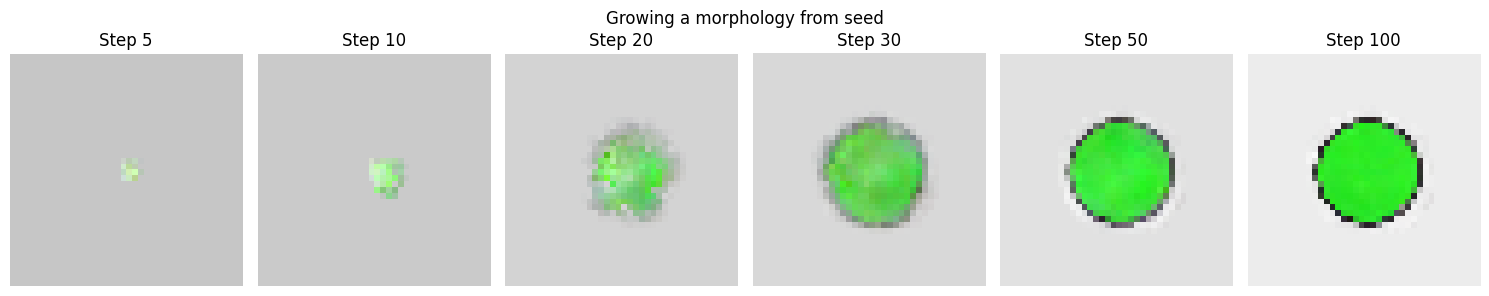

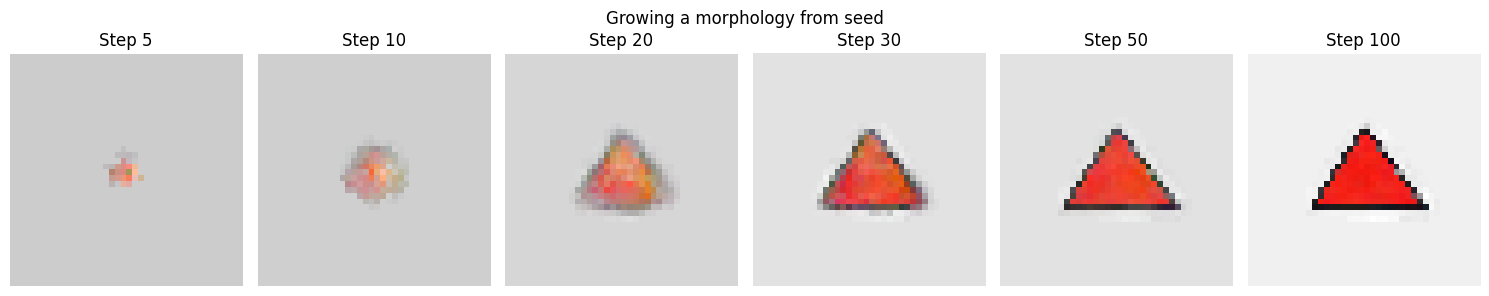

In [11]:
## Growing the morphology
def visualize_growth(nca, seed, steps_to_show=[5, 10, 20, 30, 50, 100]):
    x = seed.clone()
    fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
    fig.suptitle("Growing a morphology from seed")

    current_step = 0
    with torch.no_grad():
        for i, target_step in enumerate(steps_to_show):
            steps_needed = target_step - current_step
            for _ in range(steps_needed):
                x = nca(x)
            current_step = target_step

            # Show RGB channels
            img = x[0, :4].permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
            axes[i].imshow(img)
            axes[i].set_title(f"Step {target_step}")
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Call it with a fresh seed
visualize_growth(nca, seeds[0].unsqueeze(0).to(x.device))
visualize_growth(nca, seeds[1].unsqueeze(0).to(x.device))
visualize_growth(nca, seeds[2].unsqueeze(0).to(x.device))




In [12]:
## Damage experiments

def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x



def visualize_regeneration(nca, seed, shape_idx, base, damage,
                            channels=4, steps=200, device=DEVICE):

    if callable(seed):
        x = seed(shape_idx).to(device)
    else:
        x = seed.clone().to(device)

    # Damage: remove right half
    x = apply_damage(x, damage)

    frames        = [x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()]
    loss_recovery   = []
    capture_steps   = [25, 50, 100, 150, 199]

    with torch.no_grad():
        for t in range(steps):
            x = nca(x)

            l = (base[0:1] - x[:, :4]).pow(2).mean().item()

            loss_recovery.append(l)

            if t in capture_steps:
                frames.append(
                    x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                )

    fig = plt.figure(figsize=(20, 9))
    fig.suptitle(f"Regeneration after damage — Shape {shape_idx}", fontsize=13)

    # Row 1: visual frames
    titles = ['damaged'] + [f't={t}' for t in capture_steps]
    for i, (frame, title) in enumerate(zip(frames, titles)):
        ax = fig.add_subplot(2, len(frames), i + 1)
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')

    ax_loss = fig.add_subplot(2, 2, 3)
    ax_loss.plot(loss_recovery, color='blue', linewidth=1.5)
    ax_loss.set_title("Reconstruction Loss During Recovery")
    ax_loss.set_xlabel("NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)
    # Mark capture steps
    for t in capture_steps:
        ax_loss.axvline(x=t, color='gray', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return loss_recovery

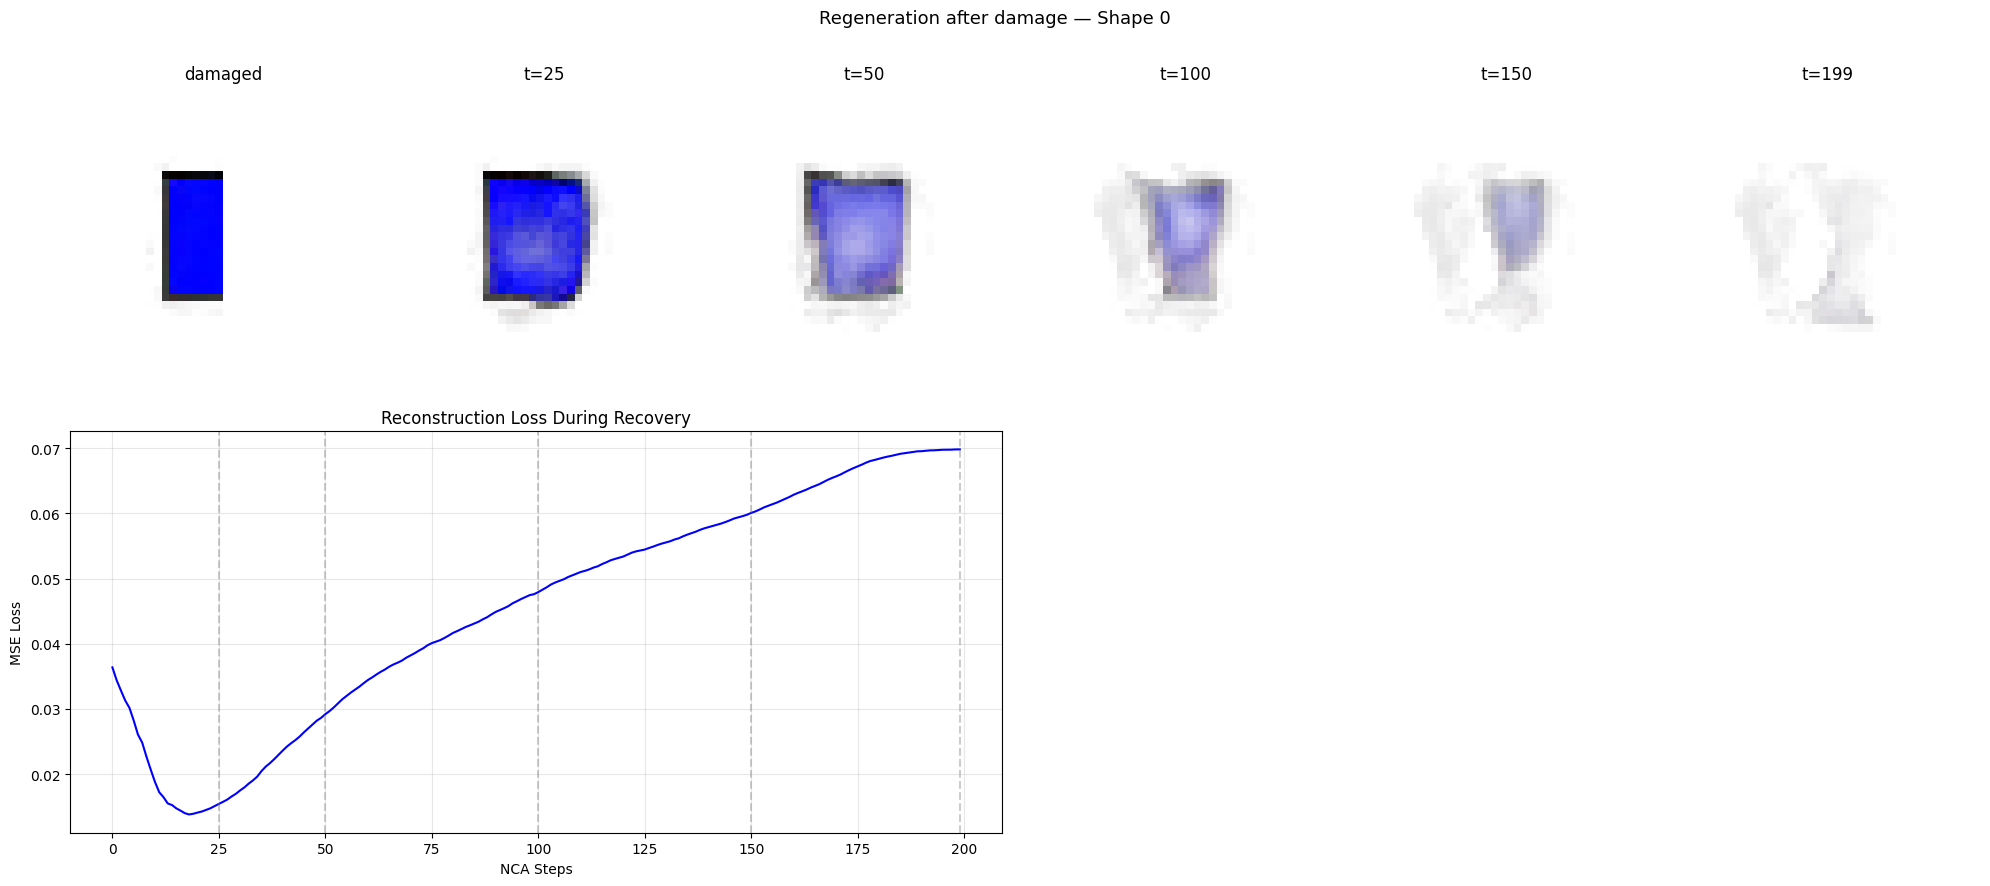

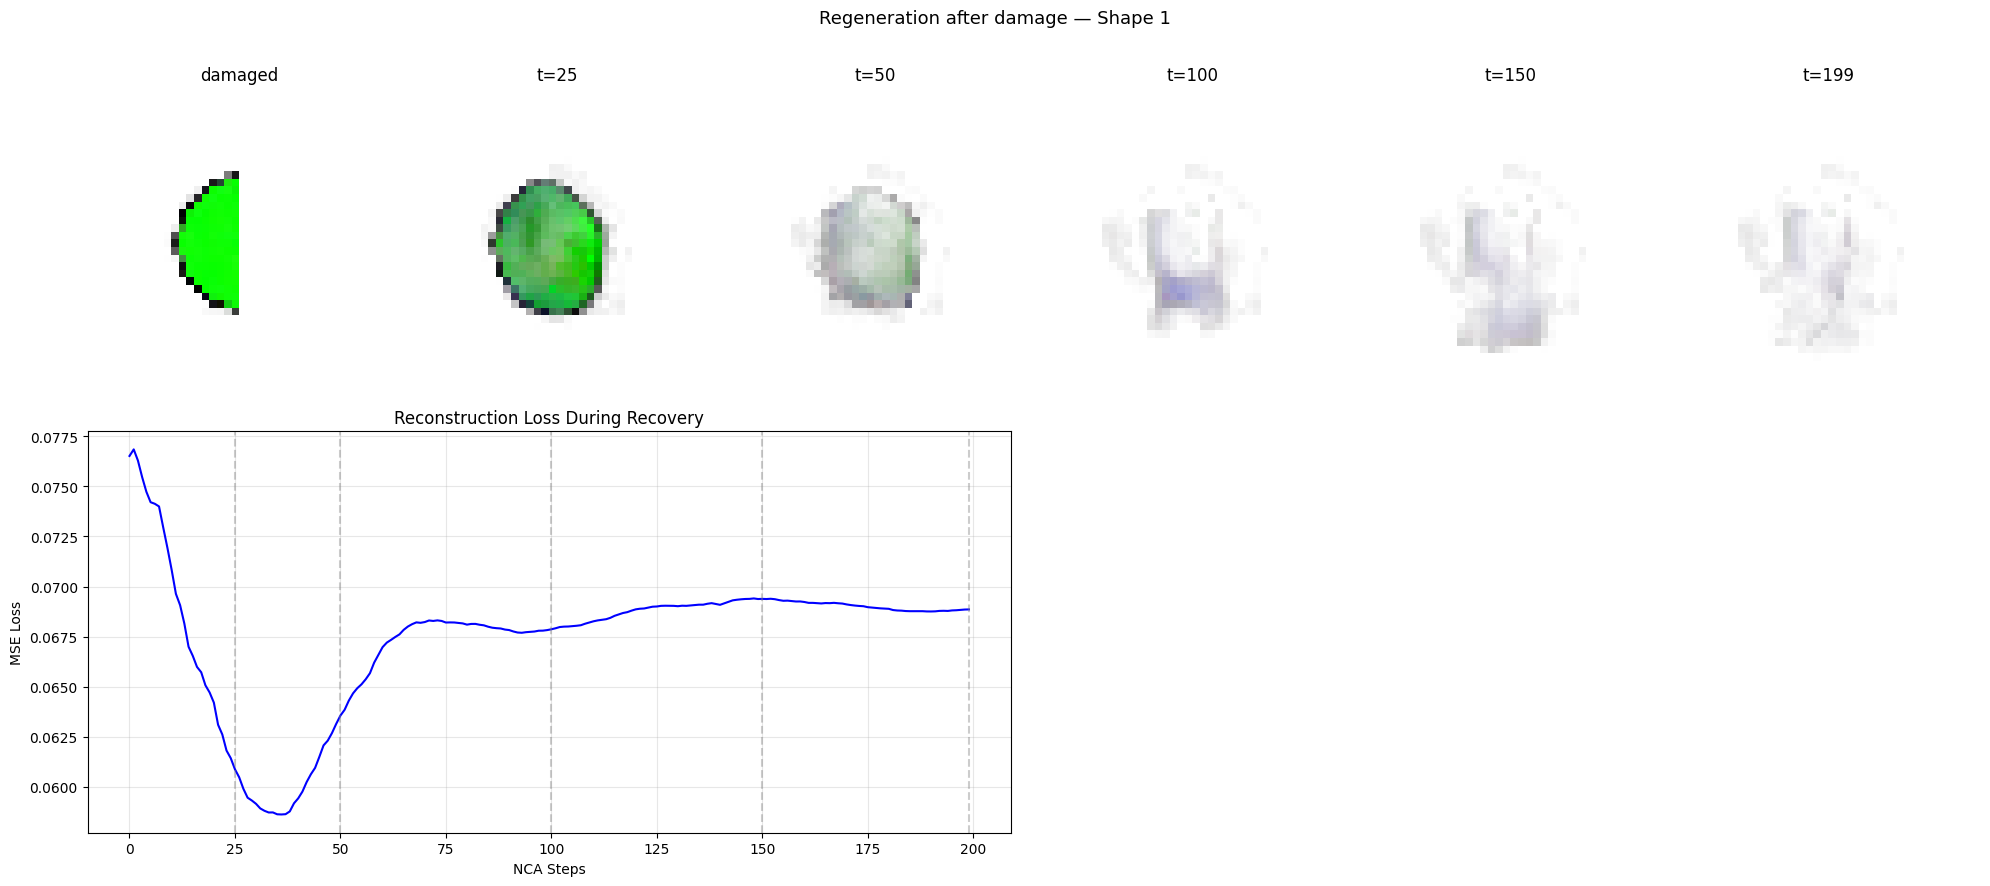

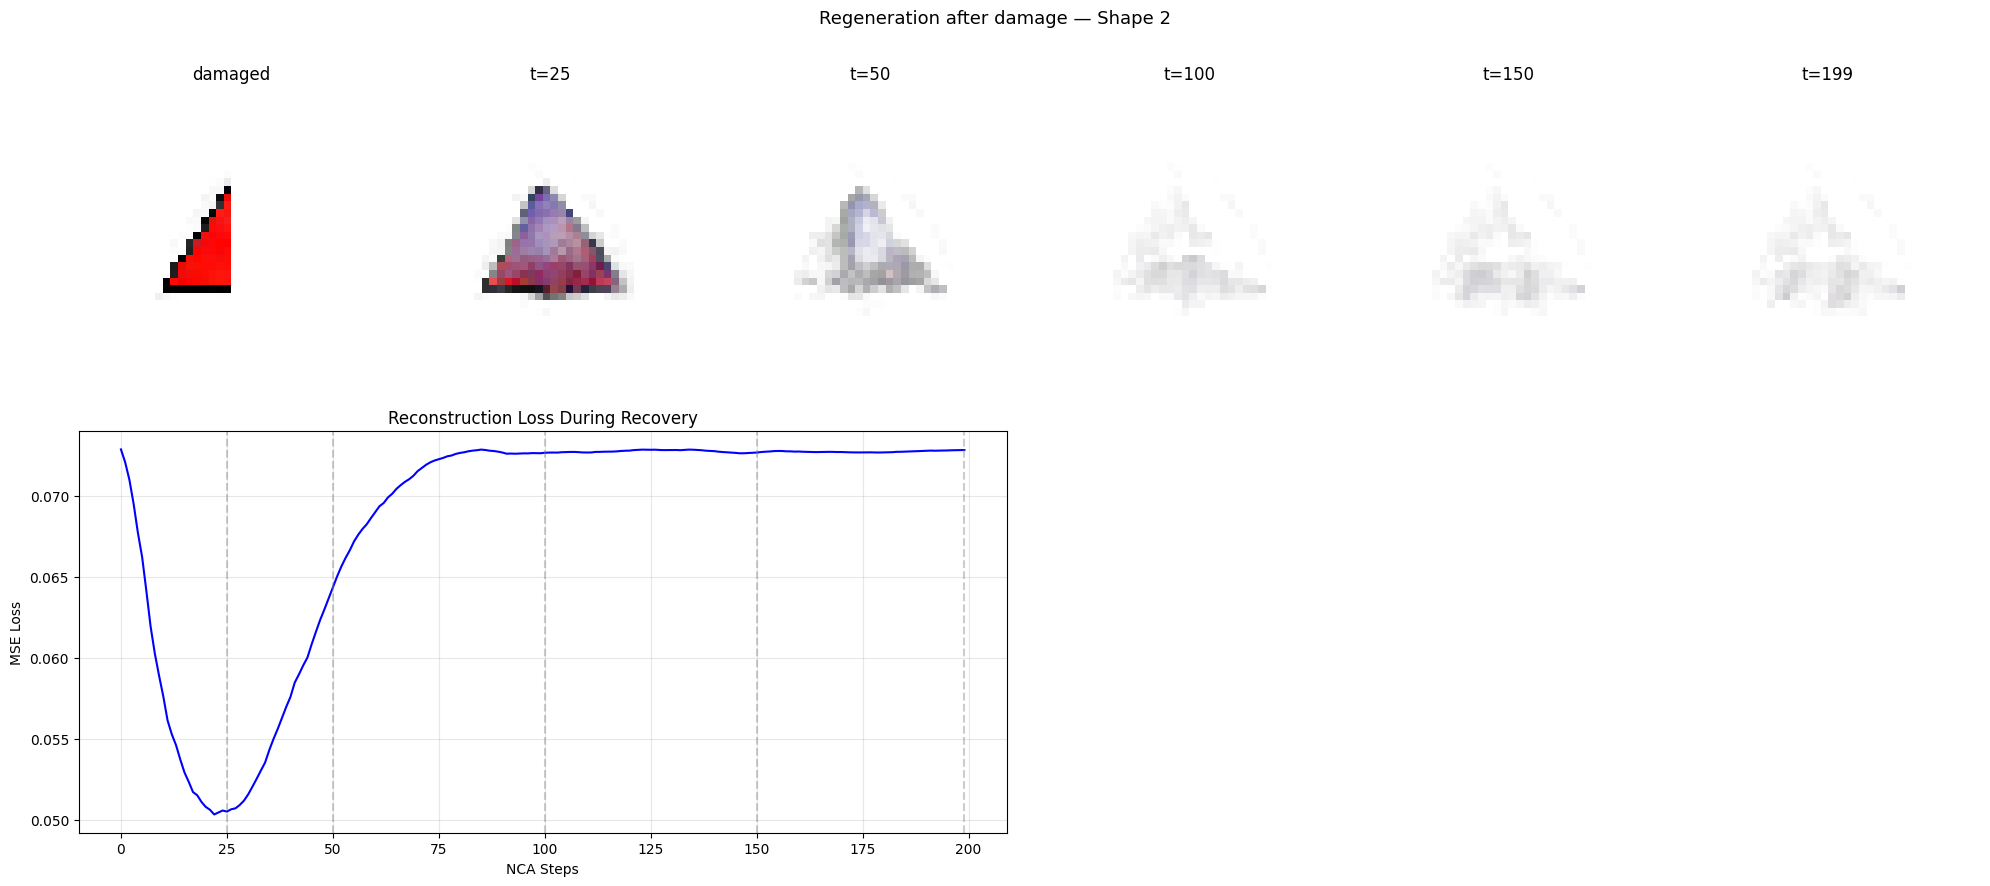

In [13]:
for shape_idx in range(3):
    visualize_regeneration(nca, pools[shape_idx][0:1].to(DEVICE), shape_idx, base, "right_half" )

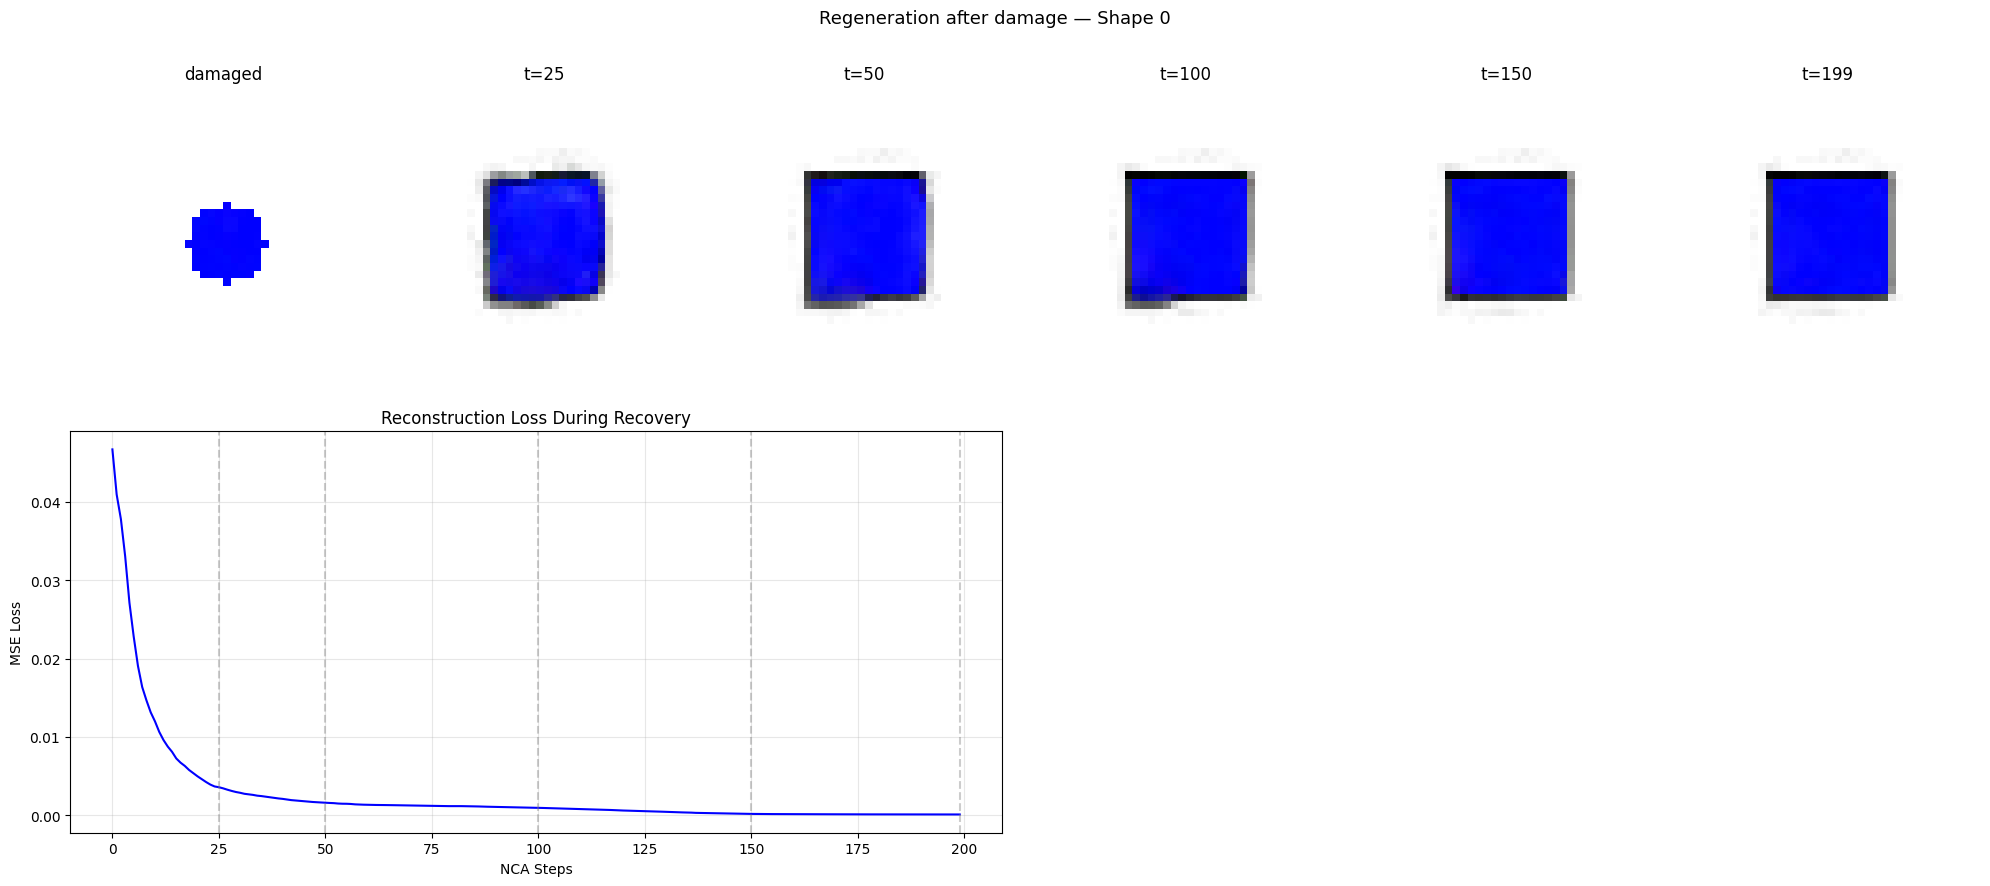

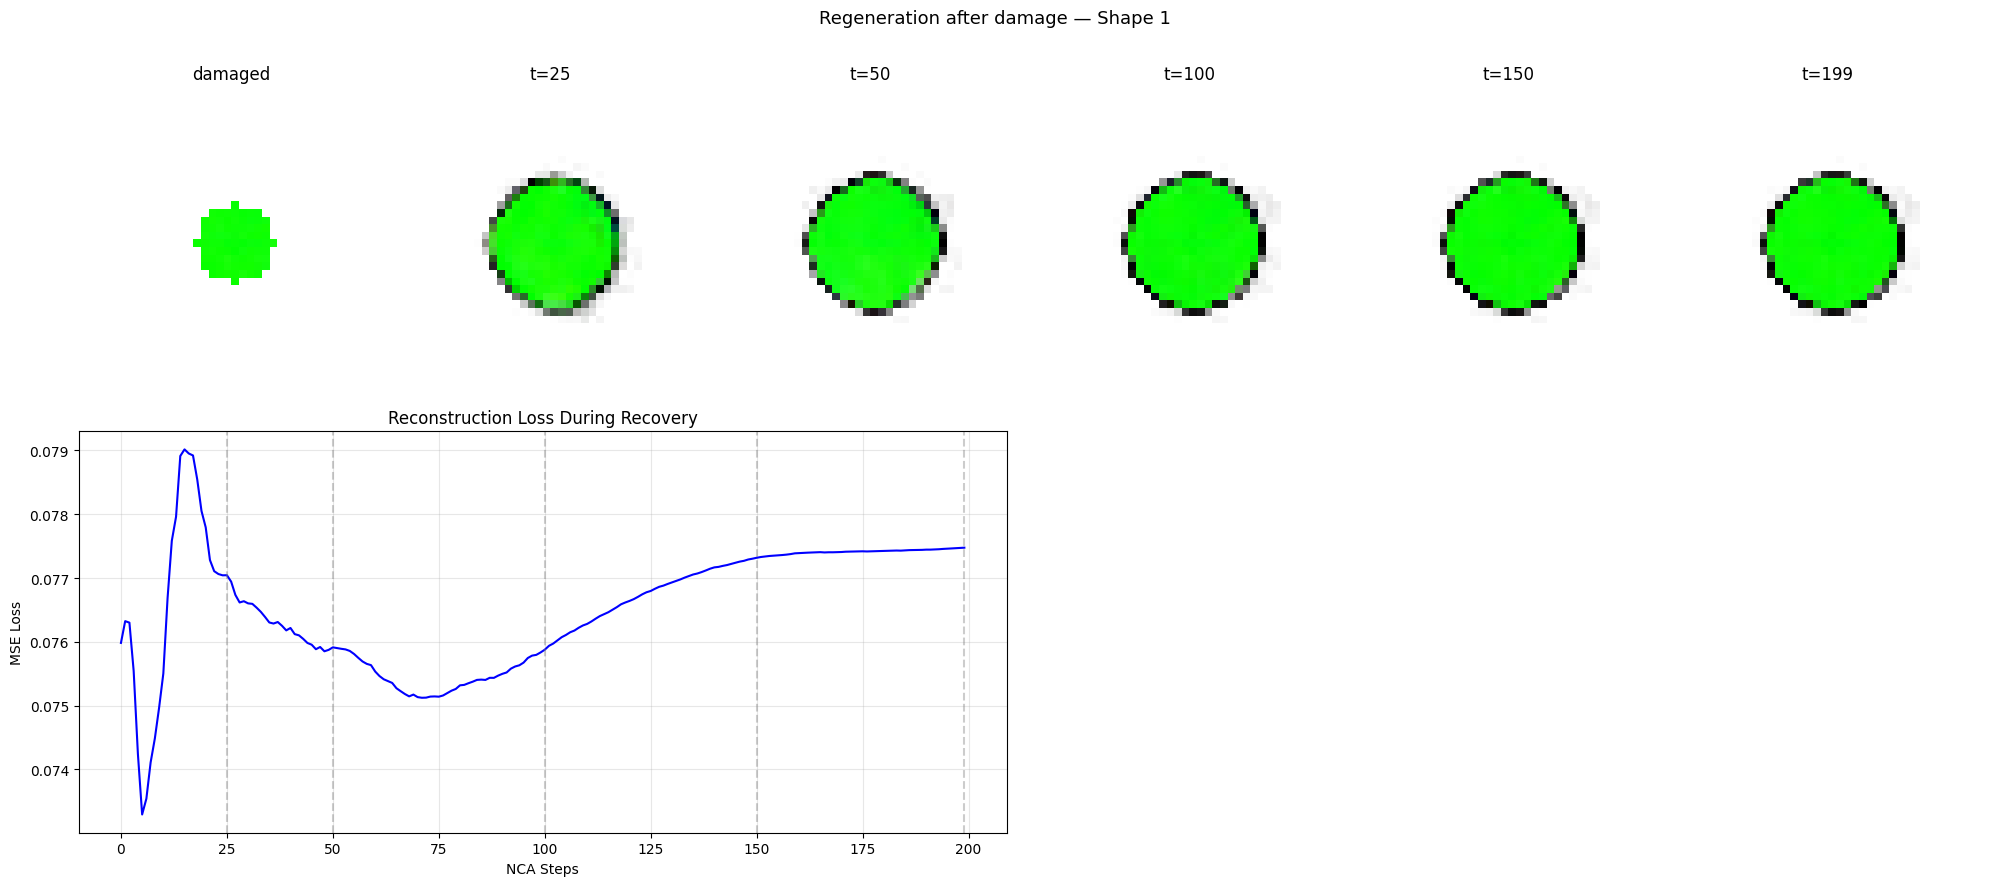

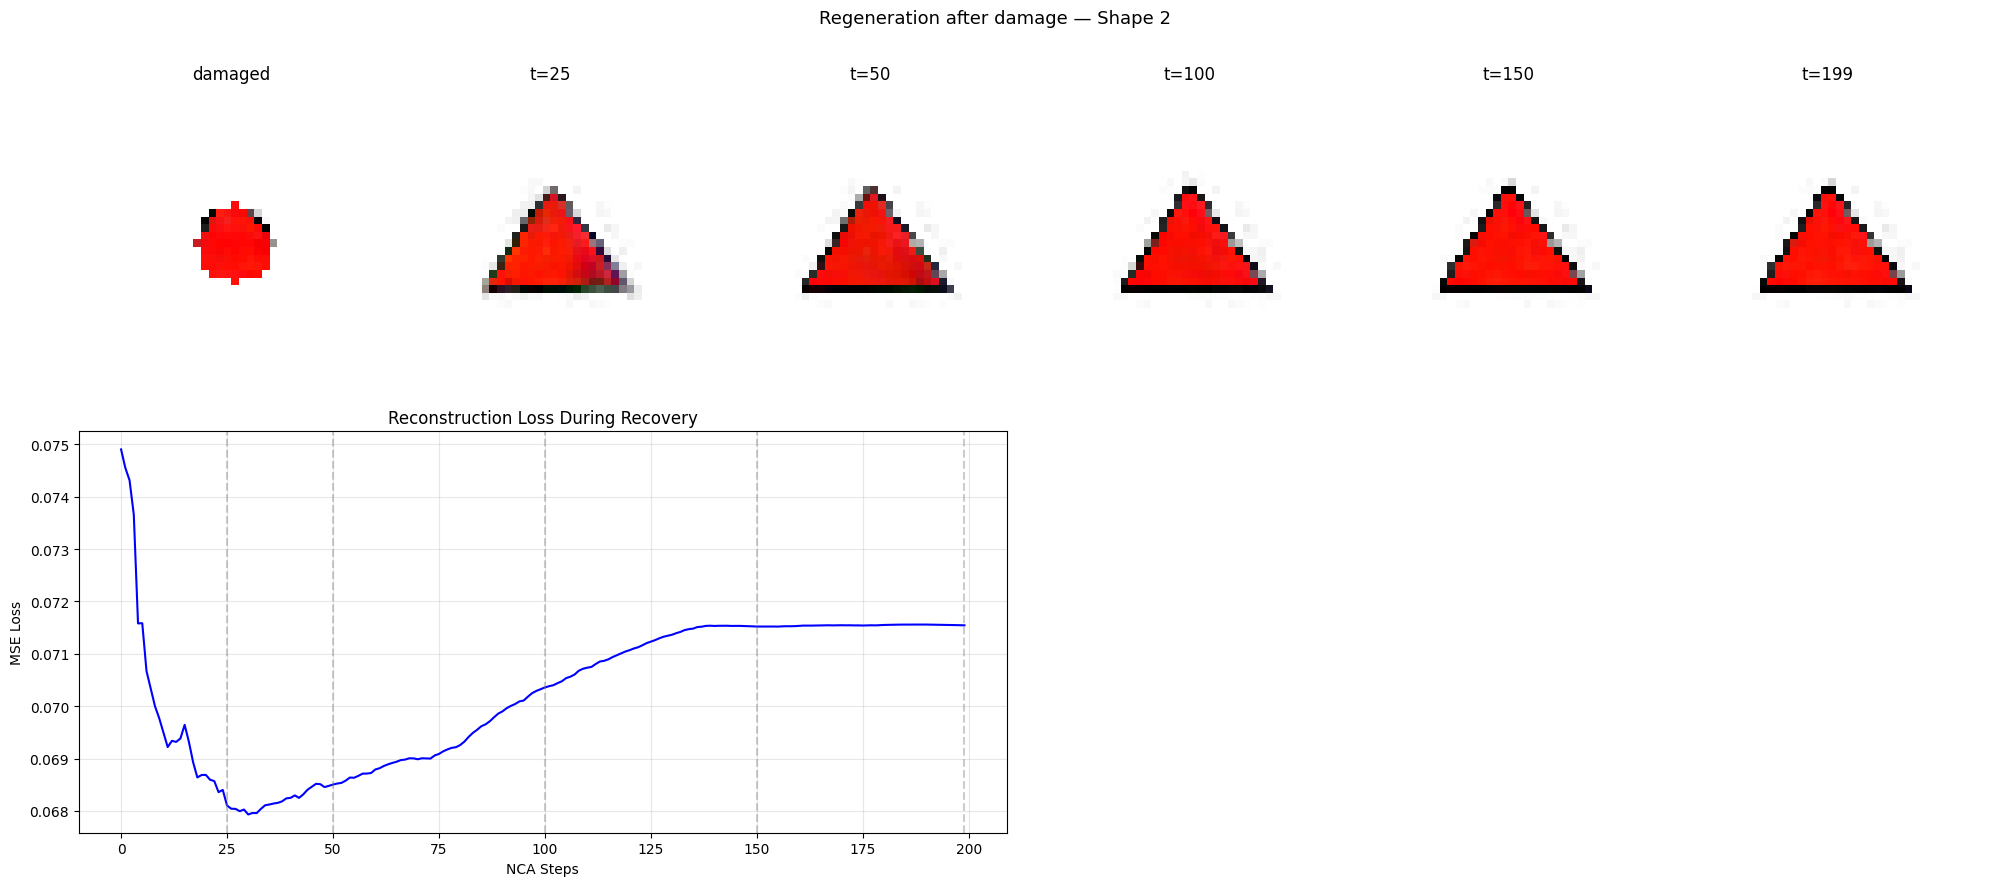

In [14]:
for shape_idx in range(3):
    visualize_regeneration(nca, pools[shape_idx][0:1].to(DEVICE), shape_idx, base, "small_circle" )

In [15]:
del nca
del optim
torch.cuda.empty_cache()